# 05. Финальная модель

По итогам ноутбука 04 лучшая конфигурация — XGBoost на признаках с target
encoding и текстом, обучение на log(price)

Здесь мы подбираем гиперпараметры, обучаем финальную модель на train+val
и смотрим на тест

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import json

import joblib
import pandas as pd
from IPython.display import Image, display

from src.config import MODELS_DIR, RUNS_DIR, TARGET
from src.models.evaluate import compute_metrics, error_analysis, format_metrics
from src.models.experiments import get_splits, load_prepared
from src.models.interpret import (
    builtin_importance,
    group_importance,
    plot_group_importance,
    plot_importance,
    plot_prediction_quality,
)
from src.utils.seed import set_seed
from src.utils.warnings import silence_blas_warnings

silence_blas_warnings()
set_seed()
pd.set_option("display.width", 200)

/Users/dianochka_l/Desktop/ProjectML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df = load_prepared()
train, val, test = get_splits(df)

21:44:43 | INFO    | src.data.split | train  62914 строк (63.5%) | средняя цена 1518
21:44:43 | INFO    | src.data.split | val    16223 строк (16.4%) | средняя цена 1509
21:44:43 | INFO    | src.data.split | test   19888 строк (20.1%) | средняя цена 1504
21:44:44 | INFO    | src.data.split | Проверка утечки: {'shared_groups': 0, 'shared_dedup_keys': 0}


## 1. Подбор гиперпараметров

Перебор ведёт Optuna.. она строит модель того, какие области пространства
параметров выглядят перспективно, и не тратит попытки на заведомо плохие
комбинации, как это делает поиск по сетке.

Подбирали для двух семейств — XGBoost (лидер сравнения) и ExtraTrees
(другое по устройству семейство с близким качеством). Оптимизировали MAE...

Запуск: `python -m src.models.experiments --stage tuning --trials 25`

In [3]:
studies = {}
for model_type in ["xgboost", "extra_trees"]:
    path = RUNS_DIR / f"cp2_tuning_{model_type}.json"
    studies[model_type] = json.loads(path.read_text(encoding="utf-8"))
    print(f"{model_type:12s} лучший MAE: {studies[model_type]['best_mae']:.1f} $"
          f"  ({studies[model_type]['n_trials']} попыток)")

xgboost      лучший MAE: 161.0 $  (25 попыток)
extra_trees  лучший MAE: 175.6 $  (25 попыток)


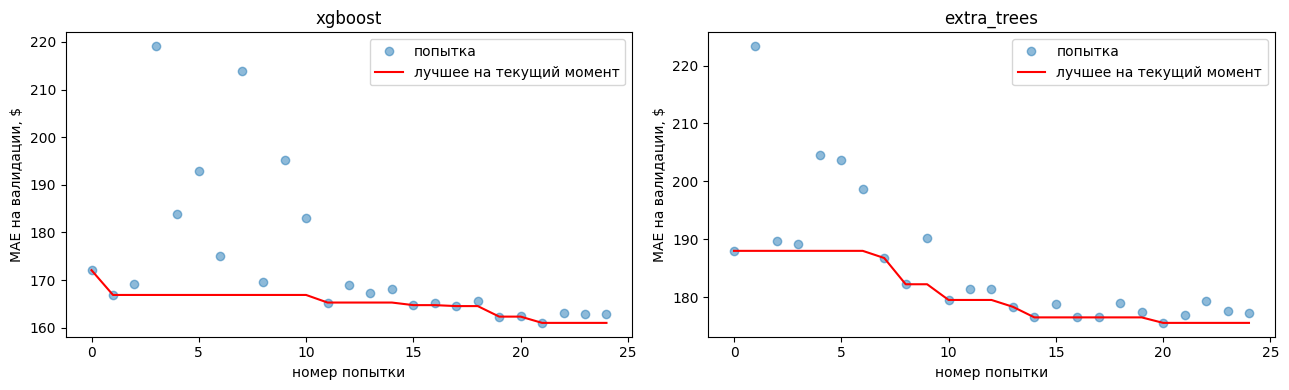

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (model_type, study) in zip(axes, studies.items()):
    trials = pd.DataFrame(study["all_trials"]).sort_values("number")
    ax.plot(trials["number"], trials["mae"], "o", alpha=0.5, label="попытка")
    ax.plot(trials["number"], trials["mae"].cummin(), color="red", label="лучшее на текущий момент")
    ax.set_xlabel("номер попытки")
    ax.set_ylabel("MAE на валидации, $")
    ax.set_title(model_type)
    ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/tuning_progress.png", bbox_inches="tight")

In [5]:
# Лучшие параметры победителя
best_type = min(studies, key=lambda k: studies[k]["best_mae"])
best_params = studies[best_type]["best_params"]
print(f"Победитель: {best_type}\n")
pd.Series(best_params).to_frame("значение")

Победитель: xgboost



,значение
n_estimators,1200.000000
learning_rate,0.031679
max_depth,10.000000
min_child_weight,13.000000
subsample,0.651461
colsample_bytree,0.738787
gamma,0.001067
reg_alpha,0.000628
reg_lambda,0.190916


## 2. Финальная модель

In [6]:
final_run = json.loads((RUNS_DIR / "cp2_final.json").read_text(encoding="utf-8"))
test_metrics = list(final_run["metrics"].values())[0]
print("Метрики на тестовой выборке:")
print(format_metrics(test_metrics))
pd.Series(test_metrics).to_frame("значение").round(3)

Метрики на тестовой выборке:
MAE=160.2$ | RMSE=300.6$ | MAPE=10.3% | R2=0.850


,значение
mae,160.176
rmse,300.610
mape,10.343
r2,0.850
median_ae,96.847


In [7]:
pipeline = joblib.load(MODELS_DIR / "final_model.pkl")
predictions = pipeline.predict(test)
y_test = test[TARGET].to_numpy()
print(format_metrics(compute_metrics(y_test, predictions)))

MAE=160.2$ | RMSE=300.6$ | MAPE=10.3% | R2=0.850


## 3. Где модель ошибается

Средний MAE скрывает распределение ошибки по сегментам.

In [8]:
error_analysis(y_test, predictions, bins=5)

,n,mean_price,mae
price_bin,,,
"(299.999, 945.0]",4000,774.6,96.1
"(945.0, 1208.0]",3957,1078.6,105.7
"(1208.0, 1475.0]",4007,1338.1,112.4
"(1475.0, 1905.0]",3955,1668.2,151.1
"(1905.0, 10000.0]",3969,2666.4,336.2


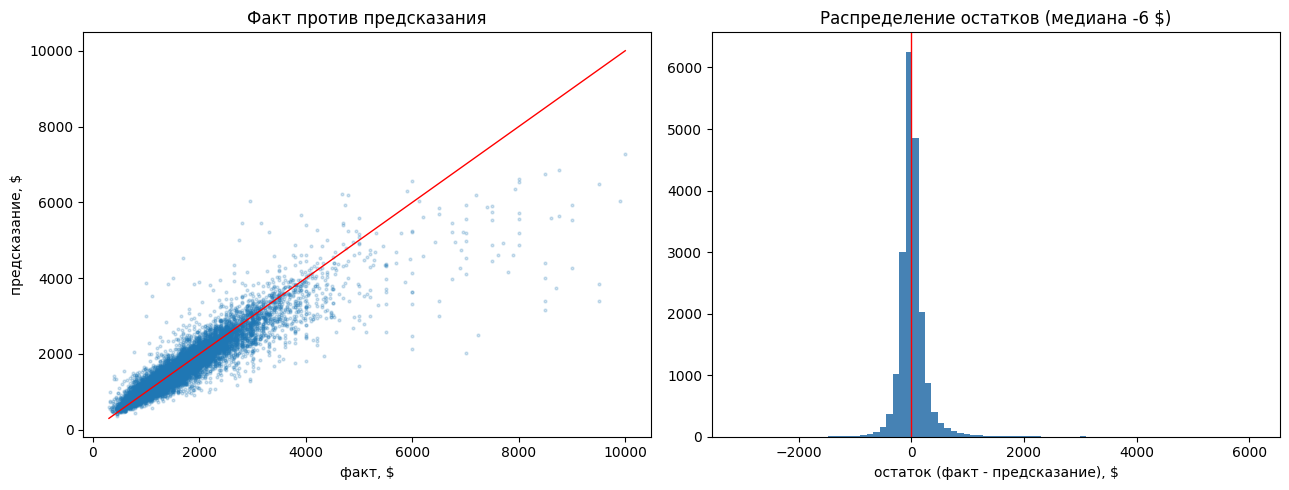

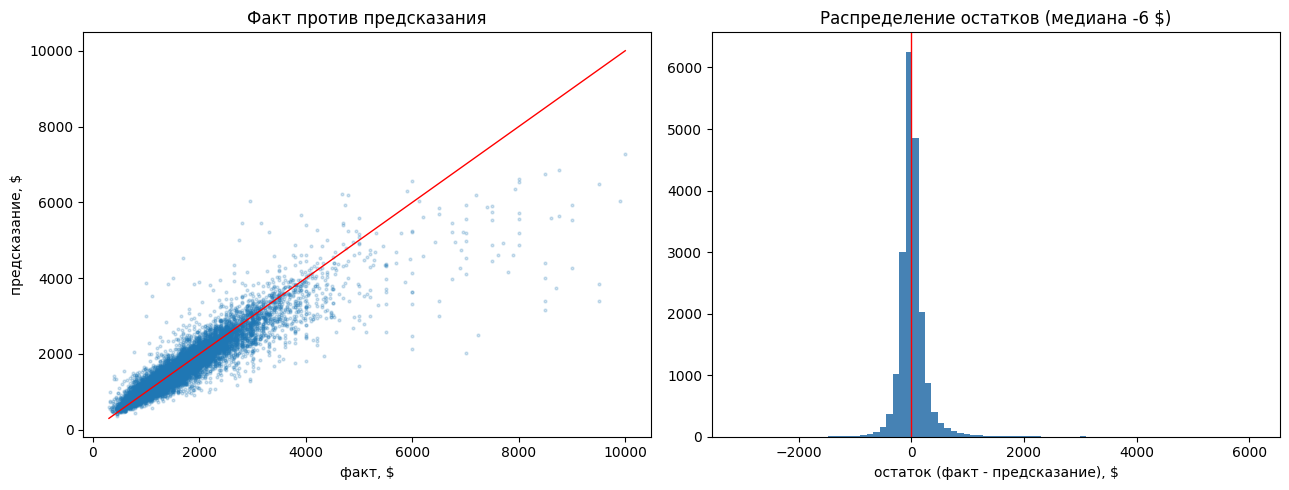

In [9]:
plot_prediction_quality(y_test, predictions)
display(Image("../reports/figures/final_predictions.png"))

## 4. Интерпретируемость
Если в топе важности окажется что-то бессмысленное, это первый признак утечки — проверять надо до выкатки,
а не после

,feature,importance
0,high_card__cityname,0.155275
1,num__bathrooms,0.085253
2,low_card__state_CA,0.064180
3,num__log_square_feet,0.042563
4,high_card__state,0.037545
5,low_card__source_GoSection8,0.036826
6,low_card__state_NE,0.035582
7,num__square_feet,0.031092
8,low_card__source_RentLingo,0.019080
9,num__total_rooms,0.018704


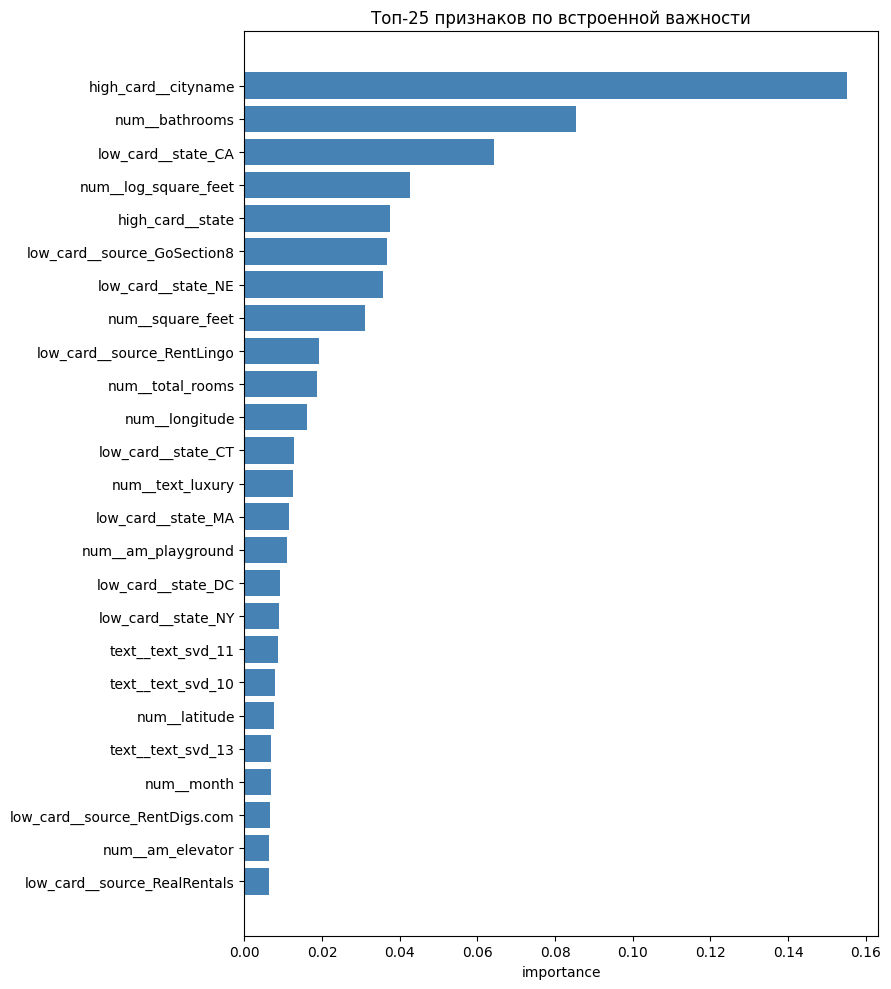

In [13]:
importance = builtin_importance(pipeline, top=25)
plot_importance(importance, title="Топ-25 признаков по встроенной важности")
importance.head(15)

,% важности
group,
категориальные,30.100000
числовые характеристики,27.799999
город и штат,19.299999
текст объявления,15.500000
удобства,6.800000
питомцы,0.500000


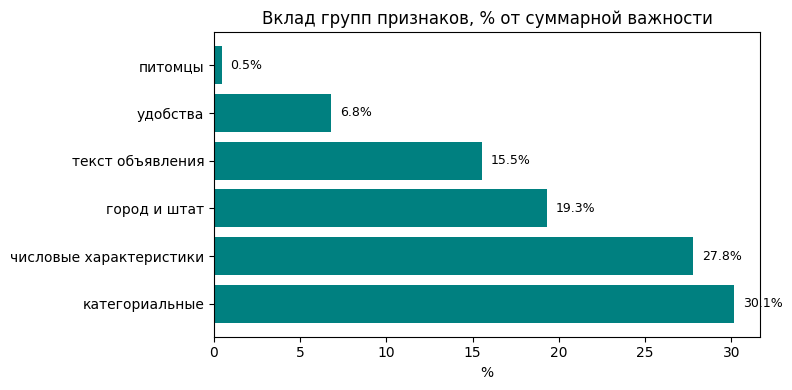

In [ ]:
groups = group_importance(builtin_importance(pipeline, top=1000))
plot_group_importance(groups)
(groups * 100).round(1).to_frame("% важности")

## 5. Выводы

- сравнены 11 моделей от линейных до бустингов и ансамблей
- проверены шесть гипотез, каждая с измеренным эффектом
- подобраны гиперпараметры для двух семейств моделей через Optuna
- проверено снижение размерности и честно показано, что оно не помогает
- финальная модель обучена на train+val и оценена на нетронутом тесте

**Обоснование выбора финальной модели** XGBoost выбран не потому, что
«бустинг обычно лучше», а по трём измеренным причинам:
1. лучший MAE на валидации среди всех проверенных моделей
2. лучшие RMSE и R2, то есть он реже допускает крупные промахи
3. обучается за 18 секунд против 49 у ExtraTrees и 172 у ансамбля —
   при прочих равных дешёвая модель предпочтительнее

Ансамбли (Voting, Stacking) проверялись и проиграли... их базовые модели
слишком похожи, усреднение почти одинаковых предсказаний ничего не даёт,
а времени требует в десять раз больше